In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom, norm_stds
from models.graph_transformer import GraphTransformer
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")

device = torch.device(torch.cuda.current_device())


protein_name = "chignolin"
gen_mode = "langevin" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = None # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
eval_folder = f"./saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"

# min-flux endpoints (not using for now)
cluster_endpoints_path = Path(
        os.path.join(
            "evaluate",
            "saved_references",
            f"saved_cluster_endpoints_{protein_name.upper()}.npy",
        )
    )

pdb_file = f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

# Load samples from the ground truth simulations to serve as training data
dataset = DEShawDataset(
    data_root="/data/sanjeevr/Reference_MD_Sims",
    molecule=Molecules[protein_name.upper()],
    simulation_id=0,
    atom_selection=AtomSelection.A_CARBON,
    return_bond_graph=False,
    transform=to_angstrom,
    align=False,
)

gt_traj = 10 * torch.tensor(dataset.traj.xyz)  # convert to angstroms
gt_traj -= gt_traj.mean(1, keepdims=True)  # center

n_atoms = gt_traj.shape[1]

# Load topology from pdb file
topology = md.load(pdb_file).topology

# Load cluster centers
cluster_centers_path = Path(
    os.path.join(
        "evaluate",
        "saved_references",
        f"saved_cluster_centers_{protein_name.upper()}.npy",
    )
)
cluster_coords = np.load(cluster_centers_path)

iid_sample_path = Path(os.path.join(os.path.dirname(eval_folder), "main_eval_output_iid"))
# Get TICA
tic_evaluator = TicEvaluator(
    val_data=None,
    mol_name=protein_name,
    eval_folder=iid_sample_path,
    data_folder="datasets",
    folded_pdb_folder="datasets/folded_pdbs",
    bins=101,
    evalset="testset",
)
# assign cluster centers to the reference samples
# TODO: TIC transformation is being done twice, need to cache the result
cluster_assignments = torch.tensor(discretize_trajectory(
    gt_traj, tic_evaluator, cluster_coords
))

# Get TIC features
sample_tic_features = tic_evaluator.get_tic_features(gt_traj, tic_evaluator.folded)
transformed_samples = tic_evaluator.tica(sample_tic_features)

KeyboardInterrupt: 

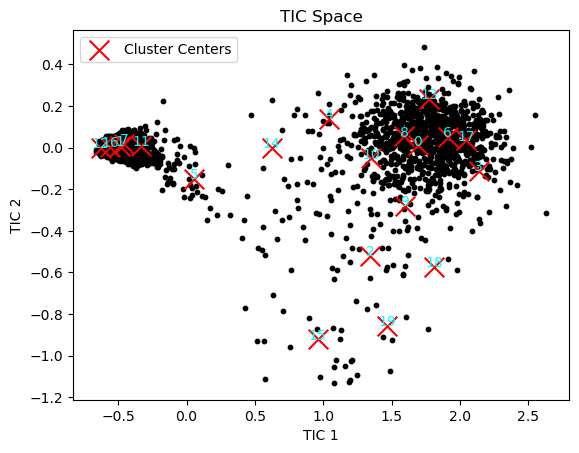

In [ ]:
# Plot the TICA space with black points and red 'x' markers for cluster centers
plt.figure()
plt.scatter(transformed_samples[::100, 0], transformed_samples[::100, 1], c='black', s=10)
plt.scatter(cluster_coords[:, 0], cluster_coords[:, 1], c='red', s=200, marker='x', label='Cluster Centers')

# Add a text label above each cluster center with its index
for i, (x, y) in enumerate(cluster_coords):
    plt.text(x, y, str(i), color='cyan', fontsize=10, ha='center')

# Set plot title and axis labels
plt.title("TIC Space")
plt.xlabel("TIC 1")
plt.ylabel("TIC 2")

# Show the plot
plt.legend()
plt.show()

In [ ]:
def get_gt_committor_probs(tic_samples, start_cluster, end_cluster, clusters, tic):
    n_samples = tic_samples.shape[0]
    
    
    # Digitize samples into bins
    bins_x = np.digitize(tic_samples[:, 0], tic.bin_edges_x) - 1
    bins_y = np.digitize(tic_samples[:, 1], tic.bin_edges_y) - 1
    
    # Clip to ensure all indices are within bounds
    bins_x = np.clip(bins_x, 0, tic.bins - 1)
    bins_y = np.clip(bins_y, 0, tic.bins - 1)
    
    # Create bin index based on (x, y) bin pairs
    bin_idx = bins_x * tic.bins + bins_y

    if os.path.exists(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy"):
        committor_probs = np.load(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy")
        return committor_probs[bin_idx]
    
    # Initialize committor probabilities tensor
    committor_probs = torch.zeros(tic.bins ** 2)
    bin_counts = torch.zeros(tic.bins ** 2)
    
    # Boolean masks for start and end cluster transitions
    is_start = (clusters == start_cluster)
    is_end = (clusters == end_cluster)
    
    last_committor = None
    last_transition_idx = None

    # Iterate over samples to assign committor probabilities
    for i in tqdm(range(n_samples)):
        bin_counts[bin_idx[i]] += 1
        if last_transition_idx is not None and i <= last_transition_idx:
            # If we already determined the committor for the intermediate steps, assign and skip
            committor_probs[bin_idx[i]] += last_committor
        else:
            if is_start[i]:
                committor_probs[bin_idx[i]] += 0
                last_committor = 0
                last_transition_idx = i
            elif is_end[i]:
                committor_probs[bin_idx[i]] += 1
                last_committor = 1
                last_transition_idx = i
            else:
                # Search forward in the trajectory to find the next transition
                subsequent_clusters = clusters[i:]
                first_start = np.argmax(subsequent_clusters == start_cluster)
                first_end = np.argmax(subsequent_clusters == end_cluster)

                if (first_end == 0 or first_start > 0 and first_start < first_end):
                    last_committor = 0
                    last_transition_idx = i + first_start
                elif (first_end > 0 and (first_start == 0 or first_end < first_start)):
                    last_committor = 1
                    last_transition_idx = i + first_end
                else:
                    raise RuntimeError(f"No transition found for sample {i}")
                
                # Assign committor for current step
                committor_probs[bin_idx[i]] += last_committor
    
    # Normalize committor probabilities by bin counts
    committor_probs = committor_probs / torch.clamp(bin_counts, min=1)
    
    # Save bin-wise committor probabilities
    np.save(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy", committor_probs)
    
    return committor_probs[bin_idx]


start, end = CLUSTER_ENDPOINTS[protein_name]
probs = get_gt_committor_probs(transformed_samples, start, end, cluster_assignments, tic_evaluator)


100%|██████████| 534743/534743 [00:25<00:00, 21238.85it/s]


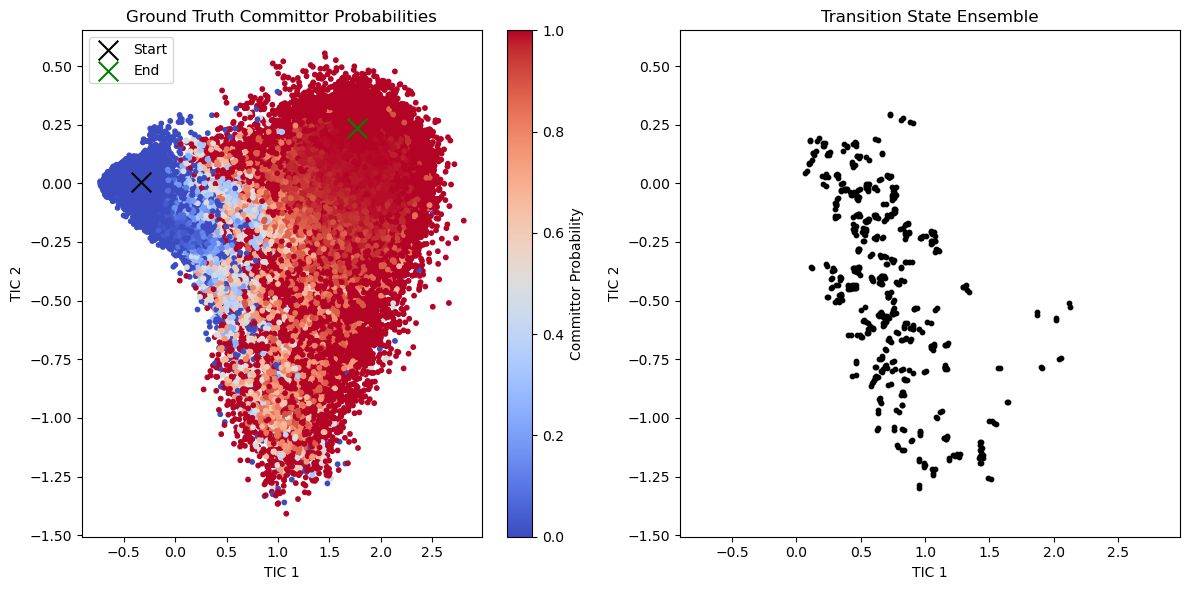

In [ ]:
import matplotlib.pyplot as plt

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First plot: Ground Truth Committor Probabilities
scatter1 = axs[0].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=probs, cmap='coolwarm', s=10)
axs[0].set_title("Ground Truth Committor Probabilities")
axs[0].set_xlabel("TIC 1")
axs[0].set_ylabel("TIC 2")
axs[0].scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[0].scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[0].legend()
plt.colorbar(scatter1, ax=axs[0], label='Committor Probability')

# Get the axis limits from the first plot
x_limits = axs[0].get_xlim()
y_limits = axs[0].get_ylim()

# Second plot: Transition State Ensemble (committor probability close to 0.5)
mask = (probs > 0.45) & (probs < 0.55)
scatter2 = axs[1].scatter(transformed_samples[mask, 0], transformed_samples[mask, 1], c='black', s=10)
axs[1].set_title('Transition State Ensemble')
axs[1].set_xlabel('TIC 1')
axs[1].set_ylabel('TIC 2')

# Apply the same axis limits as the first plot
axs[1].set_xlim(x_limits)
axs[1].set_ylim(y_limits)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


100%|██████████| 100/100 [02:31<00:00,  1.51s/it]


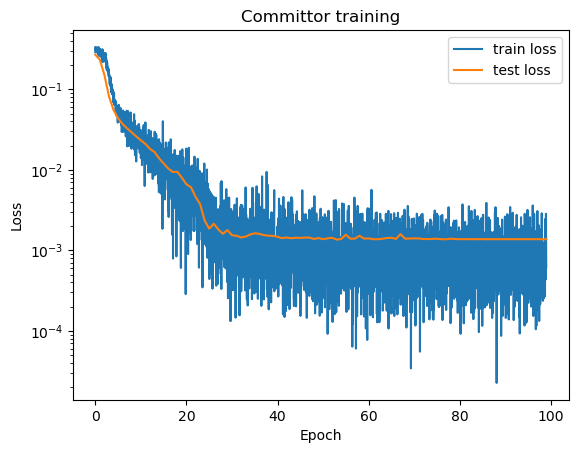

In [31]:
model = GraphTransformer(num_beads = n_atoms, hidden_nf=64, conservative=True).to(device)

class CommittorNN(torch.nn.Module):
    def __init__(self, model):
        super(CommittorNN, self).__init__()
        self.model = model
        self.sigmoid = torch.nn.Sigmoid()
    def forward(self, x, h, t):
        # model returns per-residue contribution to the committor
        per_atom_contrib = self.model(x, h, t, return_energy = True)
        # sum over all atoms and pass through sigmoid to get committor probability
        committor_prob = self.sigmoid(per_atom_contrib.sum(dim = (-2, -1)))
        return committor_prob


committor_model = CommittorNN(model)

# Train the model on the sampled molecules
batch_size = 256
n_epochs = 100
max_data_size = 10000
optimizer = torch.optim.Adam(committor_model.parameters(), lr=1e-5)
scheduler = linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps = 200, \
                                                        total_steps = n_epochs * int(0.8 * max_data_size / batch_size), \
                                                        lr_min=0.0, lr_max=1.0)
train_losses = []
test_losses = []

# split sampled_mol and cluster_assignments into train test sets
gt_traj_keep = gt_traj[:max_data_size]
gt_traj_keep = gt_traj_keep - gt_traj_keep.mean(1, keepdims=True)

cluster_assignments_keep = cluster_assignments[:max_data_size]
gt_probs_keep = probs[:max_data_size]

# TODO: investigate whether the stochasticity in results is due to the random split, the random initialization of the model, or the shuffling of the dataloader
x_train, x_test, cluster_train, cluster_test, probs_train, probs_test = train_test_split(gt_traj_keep, cluster_assignments_keep, gt_probs_keep, test_size=0.2)

trainset = torch.utils.data.TensorDataset(x_train, cluster_train, probs_train)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torch.utils.data.TensorDataset(x_test, cluster_test, probs_test)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

for _ in tqdm(range(n_epochs)):
    committor_model.train()
    for x, cluster, prob in train_dataloader:
        
        optimizer.zero_grad()
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        cluster = cluster.to(device)
        prob = prob.to(device)
        start_mask = cluster == start
        end_mask = cluster == end
        transition_mask = torch.logical_and(~start_mask, ~end_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size, ]
            inputs=x,  # [batch_size, n_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        # if transition_mask.sum() > 0:
        grad_loss = grad_prob.square().sum((-2, -1)).mean()#[transition_mask].mean()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()
        
        sl_loss = (pred_prob - prob).square().mean()

        loss = sl_loss #+ 5*start_boundary_loss + 5*end_boundary_loss + grad_loss #sl_loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.detach().unsqueeze(-1))
        
    # Test the model on the test set
    committor_model.eval()
    tls = []
    for x, cluster, prob in test_dataloader:
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        cluster = cluster.to(device)
        prob = prob.to(device)
        start_mask = cluster == start
        end_mask = cluster == end
        transition_mask = torch.logical_and(~start_mask, ~end_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size, ]
            inputs=x,  # [batch_size, n_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        # if transition_mask.sum() > 0:
        grad_loss = grad_prob.square().sum((-2, -1)).mean()#[transition_mask].mean()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()

        sl_loss = (pred_prob - prob).square().mean()

        loss = sl_loss #+ 5*start_boundary_loss + 5*end_boundary_loss #+ grad_loss
        tls.append(loss.detach().unsqueeze(-1))
    
    test_loss = torch.cat(tls).sum(0) / len(tls)
    test_losses.append(test_loss.unsqueeze(-1))


train_losses = torch.cat(train_losses).cpu().numpy()
test_losses = torch.cat(test_losses).cpu().numpy()

plot_losses(train_losses, test_losses, "Committor training")


100%|██████████| 2089/2089 [00:16<00:00, 126.40it/s]


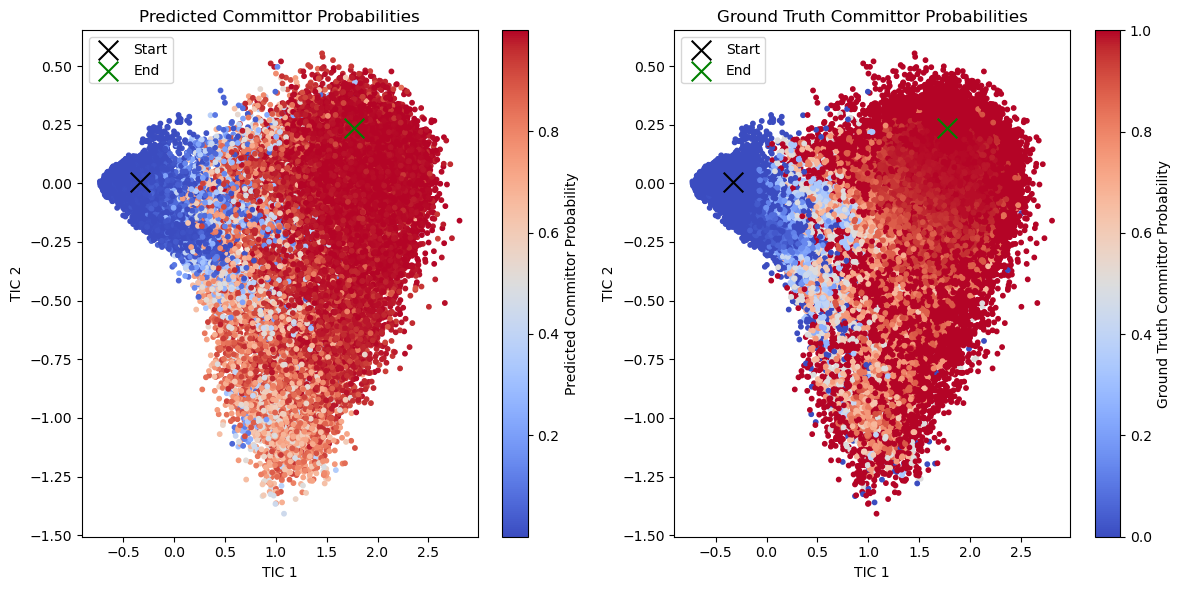

In [32]:
# Import necessary libraries
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Assuming committor_model, tic_evaluator, cluster_coords, etc., are already defined

# Evaluate the committor model and get predicted probabilities
committor_model.eval()

committor_probs = []
xs = []
for x in tqdm(gt_traj.split(batch_size)):
    x = x.to(device).requires_grad_(True)
    x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
    h = torch.eye(n_atoms).to(device)
    t = torch.zeros((x.shape[0], )).to(device)
    pred_prob = committor_model(x, h, t)
    committor_probs.append(pred_prob.detach())
    xs.append(x * norm_stds[Molecules[protein_name.upper()]])

committor_probs = torch.cat(committor_probs).cpu().detach().numpy()
xs = torch.cat(xs).cpu().detach().numpy()

# Get TICA for the ground truth data
sample_tic_features = tic_evaluator.get_tic_features(
        torch.tensor(xs), tic_evaluator.folded
    )
transformed_samples = tic_evaluator.tica(sample_tic_features)

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the predicted committor probabilities
scatter1 = axs[0].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=committor_probs, cmap='coolwarm', s=10)
axs[0].set_title('Predicted Committor Probabilities')
axs[0].set_xlabel('TIC 1')
axs[0].set_ylabel('TIC 2')
axs[0].scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[0].scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[0].legend()
plt.colorbar(scatter1, ax=axs[0], label='Predicted Committor Probability')

# Plot the ground truth committor probabilities
scatter2 = axs[1].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=probs, cmap='coolwarm', s=10)
axs[1].set_title('Ground Truth Committor Probabilities')
axs[1].set_xlabel('TIC 1')
axs[1].set_ylabel('TIC 2')
axs[1].scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[1].scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[1].legend()
plt.colorbar(scatter2, ax=axs[1], label='Ground Truth Committor Probability')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
